# Adversarial Attacks Demo with PyBox

This notebook demonstrates how to use PyBox's `AdversarialExplainer` to visualize adversarial attacks on a trained neural network. We'll train a simple CNN on CIFAR-10 images and then generate adversarial examples using various attack methods.

## Prerequisites

Make sure you have PyBox and the required dependencies installed:

For PIP

```bash
pip install torch torchvision adversarial-robustness-toolbox
pip install -e .
```

For UV (Using a Python venv >= 3.13):
```bash
uv sync
uv pip install torch torchvision adversarial-robustness-toolbox
uv pip install -e .
```

This demo uses:
- PyTorch for the neural network
- Torchvision for CIFAR-10 dataset
- ART (Adversarial Robustness Toolbox) for attack implementations
- PyBox for visualization

**Note**: This notebook trains a model from scratch, which may take several minutes. You can skip the training cell if you have a pre-trained model.

## Step 1: Import Libraries

First, let's import all the necessary libraries for this demo.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt

# PyBox imports
from pybox.visualization.plotter import Plotter
from pybox.engine import AdversarialEngine
from pybox.attacks.art_adapter import ArtAttackAdapter
from pybox.metrics import MAEMetric, MSEMetric, RMSEMetric, CosineMetric, GMDMetric

from art.estimators.classification import PyTorchClassifier

In [2]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
# Import torch transforms if needed
import torchvision.transforms as transforms
import torchvision.datasets as datasets
from torch.utils.data import DataLoader 
from art.estimators.classification import PyTorchClassifier
from sklearn.preprocessing import RobustScaler, StandardScaler, MinMaxScaler

# Add src to path to import the local module
import sys
sys.path.append(os.path.abspath("src"))

## Step 2: Define the Neural Network Model

We'll create a simple Convolutional Neural Network (CNN) that can classify CIFAR-10 images. This model will be our target for adversarial attacks.

In [3]:
# Define a simple CNN model
class SimpleModel(nn.Module):
    def __init__(self):
        super(SimpleModel, self).__init__()
        # Input: (3, 28, 28) after permuting from (28, 28, 3)
        self.conv1 = nn.Conv2d(3, 16, 3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, 3, padding=1)
        self.conv3 = nn.Conv2d(32, 64, 3, padding=1)
        
        self.pool = nn.MaxPool2d(2, 2)
        self.fc = nn.Linear(64 * 3 * 3, 10)

    def forward(self, x):
        # Permute from (N, H, W, C) to (N, C, H, W) since channels_first=False in classifier
        x = x.permute(0, 3, 1, 2)
        x = self.pool(torch.relu(self.conv1(x)))
        x = self.pool(torch.relu(self.conv2(x)))
        x = self.pool(torch.relu(self.conv3(x)))
        x = x.reshape(x.size(0), -1)  # Changed from view to reshape to handle non-contiguous tensors
        x = self.fc(x)
        return x

model = SimpleModel()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

## Step 3: Train the Model

We'll train our CNN on CIFAR-10 images resized to 28x28 pixels. This is a simplified version for demo purposes - in practice, you'd want to train longer and use the full resolution.

**Note**: This training may take 5-10 minutes depending on your hardware. You can reduce the number of epochs if needed.

In [4]:
# Simple 1-epoch training on MNIST
# Prepare transforms and training dataset and loader
transform = transforms.Compose([
    transforms.Resize((28, 28)),
    transforms.ToTensor(),
])

trainset = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
trainloader = DataLoader(trainset, batch_size=64, shuffle=True)

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# Training loop: N epoch
model.train()
epochs = 5
for epoch in range(epochs):
    running_loss = 0.0
    for batch_idx, (inputs, targets) in enumerate(trainloader):
        # inputs: (N, 3, 28, 28) -> convert to (N, 28, 28, 3)
        inputs = inputs.permute(0, 2, 3, 1).to(device)  # (N, 28, 28, 3)
        targets = targets.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        if batch_idx % 200 == 199:  # print every 200 mini-batches
            print(f"[Epoch {epoch + 1}, Batch {batch_idx + 1}] loss: {running_loss / 200:.3f}")
            running_loss = 0.0

print(f"Finished training for {epochs} epoch")


[Epoch 1, Batch 200] loss: 2.065
[Epoch 1, Batch 400] loss: 1.787
[Epoch 1, Batch 600] loss: 1.636
[Epoch 2, Batch 200] loss: 1.564
[Epoch 2, Batch 400] loss: 1.529
[Epoch 2, Batch 600] loss: 1.533
[Epoch 3, Batch 200] loss: 1.496
[Epoch 3, Batch 400] loss: 1.485
[Epoch 3, Batch 600] loss: 1.473
[Epoch 4, Batch 200] loss: 1.444
[Epoch 4, Batch 400] loss: 1.458
[Epoch 4, Batch 600] loss: 1.434
[Epoch 5, Batch 200] loss: 1.429
[Epoch 5, Batch 400] loss: 1.422
[Epoch 5, Batch 600] loss: 1.422
Finished training for 5 epoch


## Step 4: Wrap Model with ART

To use adversarial attack methods from the Adversarial Robustness Toolbox (ART), we need to wrap our PyTorch model in an ART classifier.

In [5]:
# Wrap the model in ART's PyTorchClassifier
# We use channels_first=False because we will provide input as (N, H, W, C) for plotting compatibility
classifier = PyTorchClassifier(
    model=model,
    loss=criterion,
    optimizer=optimizer,
    input_shape=(28, 28, 3),
    nb_classes=10,
    channels_first=False 
)

In [6]:
# Load CIFAR-10 test data
testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=4, shuffle=False)

class_names = {i: name for i, name in enumerate(testset.classes)}
print(f"Classes: {class_names}")

# Get a batch of images
dataiter = iter(testloader)
images, labels = next(dataiter)

# Convert to numpy for PyBox (H, W, C)
input_imgs = images.permute(0, 2, 3, 1).numpy()

print(f"Input images shape: {input_imgs.shape}")

Classes: {0: 'airplane', 1: 'automobile', 2: 'bird', 3: 'cat', 4: 'deer', 5: 'dog', 6: 'frog', 7: 'horse', 8: 'ship', 9: 'truck'}
Input images shape: (4, 28, 28, 3)


## Step 6: Generate Adversarial Examples

Now comes the exciting part! We'll use PyBox's `AdversarialExplainer` to generate and visualize adversarial examples.

The available attack methods are all from art.attack.evasion import *

We'll demonstrate different difference calculation methods to highlight how adversarial perturbations affect the images.

In [7]:
from art.attacks.evasion import CarliniL0Method, CarliniL2Method, CarliniLInfMethod, DeepFool

# Instantiate attacks using the classifier
# Limiting iterations for faster demo execution
attack_cw = CarliniL2Method(classifier=classifier, targeted=False, max_iter=10, verbose=False)
attack_df = DeepFool(classifier=classifier, max_iter=10, verbose=False)

# Wrap attacks with ArtAttackAdapter
attacks = [
    ArtAttackAdapter(attack_cw, name="CarliniL2"),
    ArtAttackAdapter(attack_df, name="DeepFool")
]

print(f"Attacks prepared: {[a.name for a in attacks]}")

Attacks prepared: ['CarliniL2', 'DeepFool']


### Mean Absolute Error (MAE) Differences

MAE calculates the absolute differences between pixels. This highlights where the adversarial perturbations are largest.

Processing images: 100%|██████████| 4/4 [00:08<00:00,  2.21s/it]


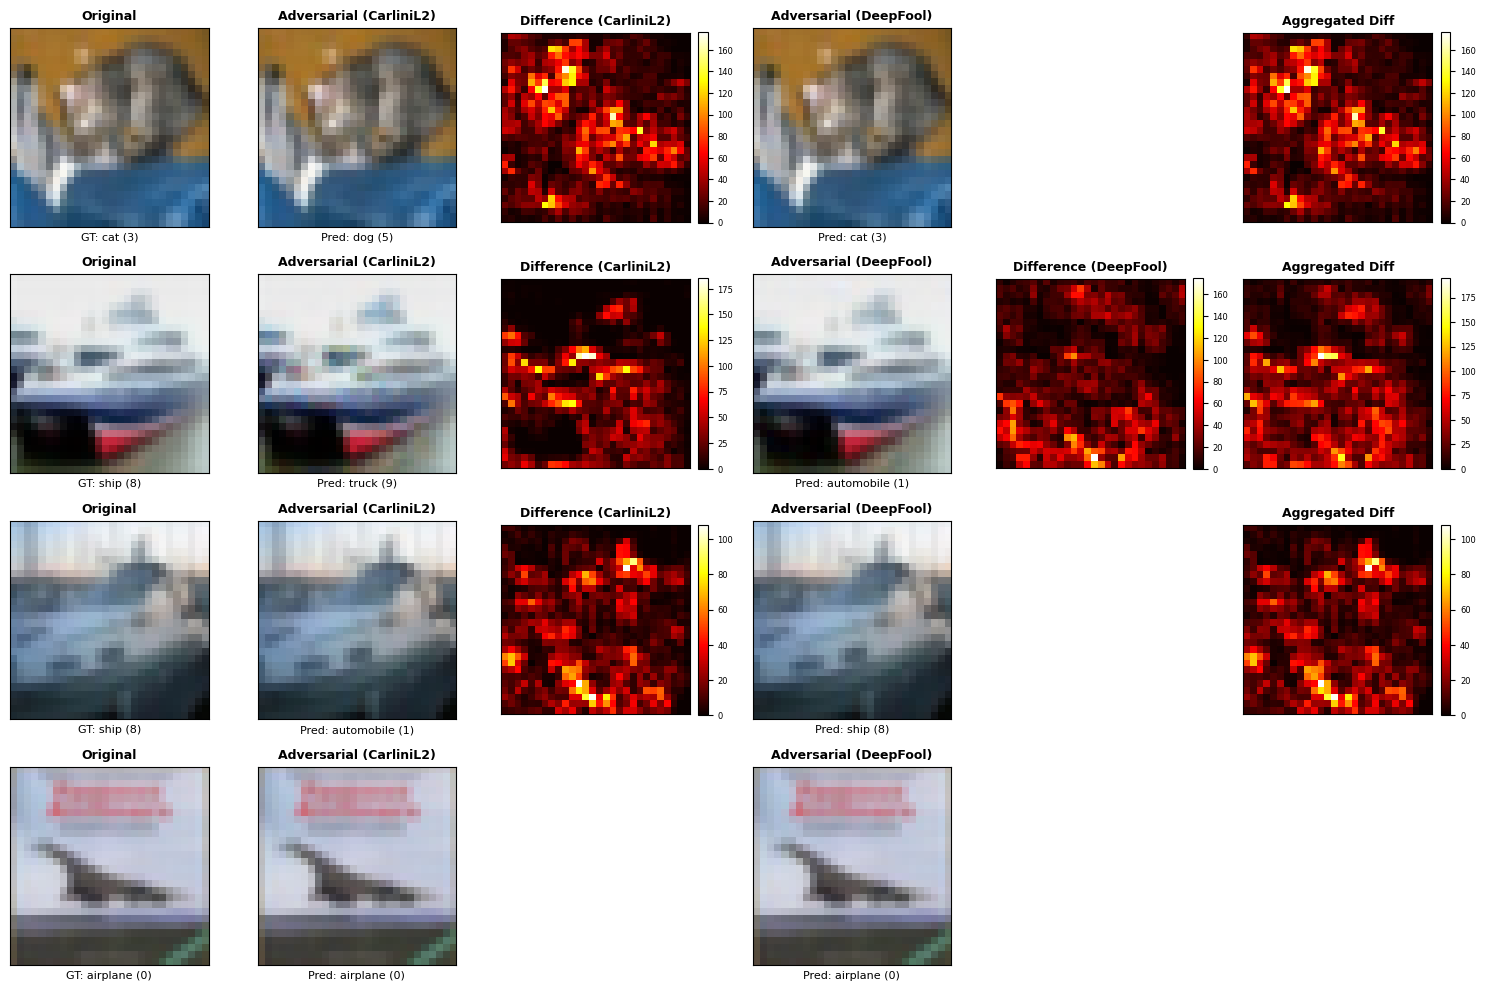

In [8]:
# Create engine with MAE metric
metric_mae = MAEMetric()
engine_mae = AdversarialEngine(
    classifier=classifier, 
    attacks=attacks, 
    metric=metric_mae
)

# Run experiment
# Note: Input images are already in correct shape (N, H, W, C)
results_mae = engine_mae.run(input_imgs, ground_truth=labels.numpy())

# Visualize
# Plotter now accepts List[ExperimentResult]
plotter = Plotter()
_ = plotter.plot(results_mae, class_names=class_names)

### Mean Squared Error (MSE) Differences

MSE squares the differences, so it emphasizes larger perturbations more strongly than MAE.

Processing images: 100%|██████████| 4/4 [00:08<00:00,  2.17s/it]


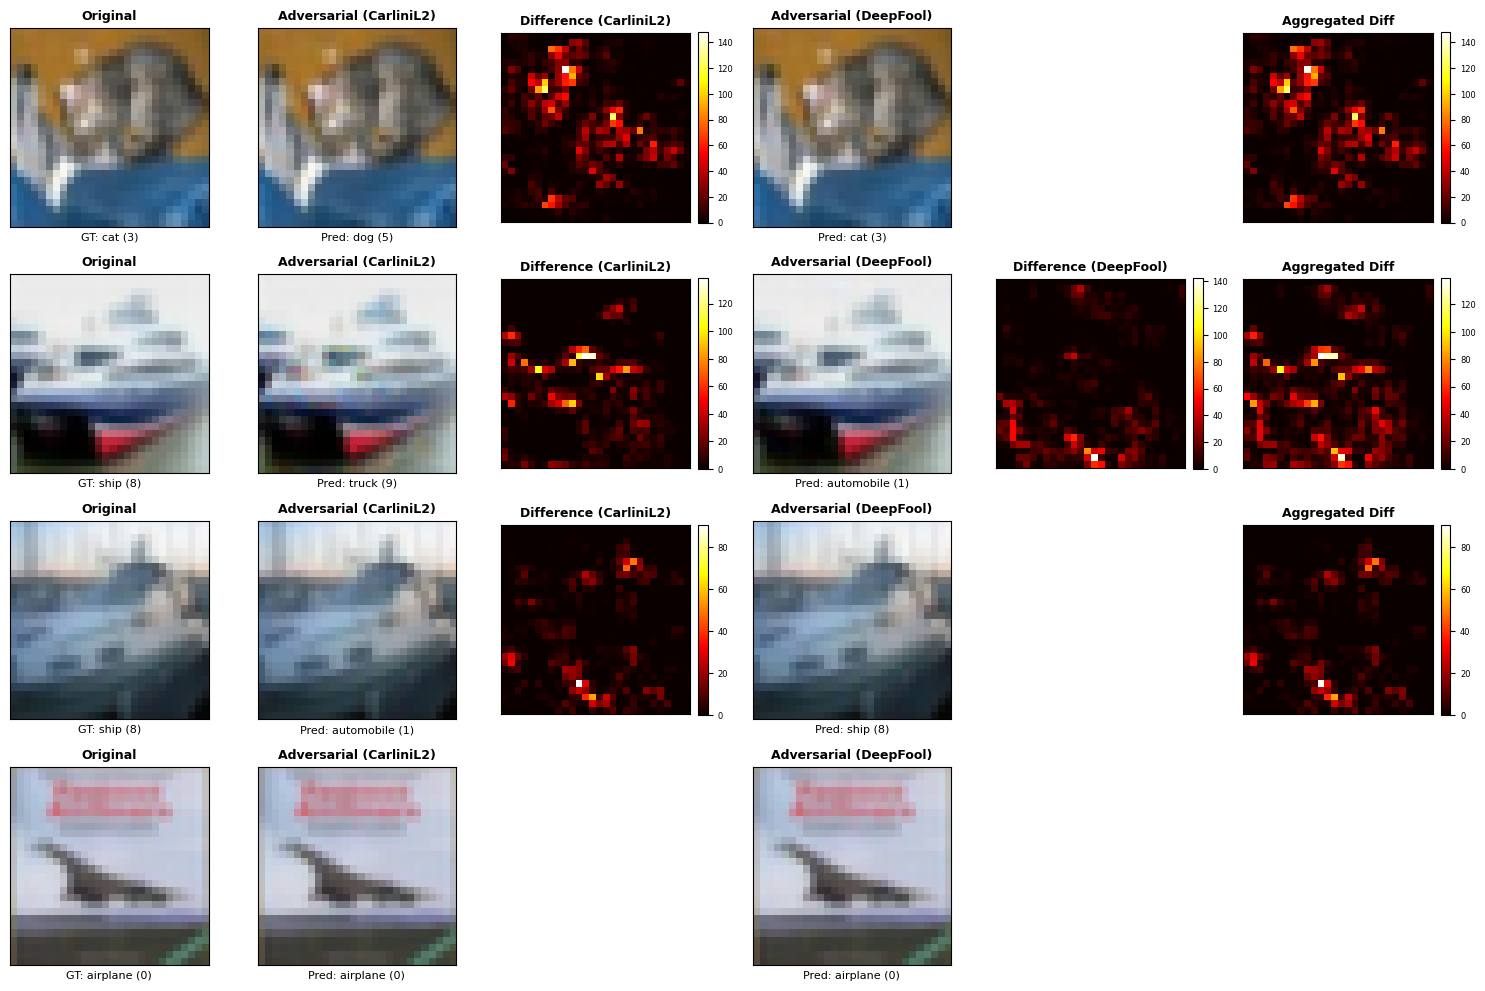

In [9]:
# Create engine with MSE metric
metric_mse = MSEMetric()
engine_mse = AdversarialEngine(
    classifier=classifier, 
    attacks=attacks, 
    metric=metric_mse
)

# Run experiment
results_mse = engine_mse.run(input_imgs, ground_truth=labels.numpy())

# Visualize
_ = plotter.plot(results_mse, class_names=class_names)

### Root Mean Square Error (RMSE) Differences

RMSE is the square root of MSE, providing a normalized measure of pixel differences that can be easier to interpret.

Processing images: 100%|██████████| 4/4 [00:08<00:00,  2.22s/it]


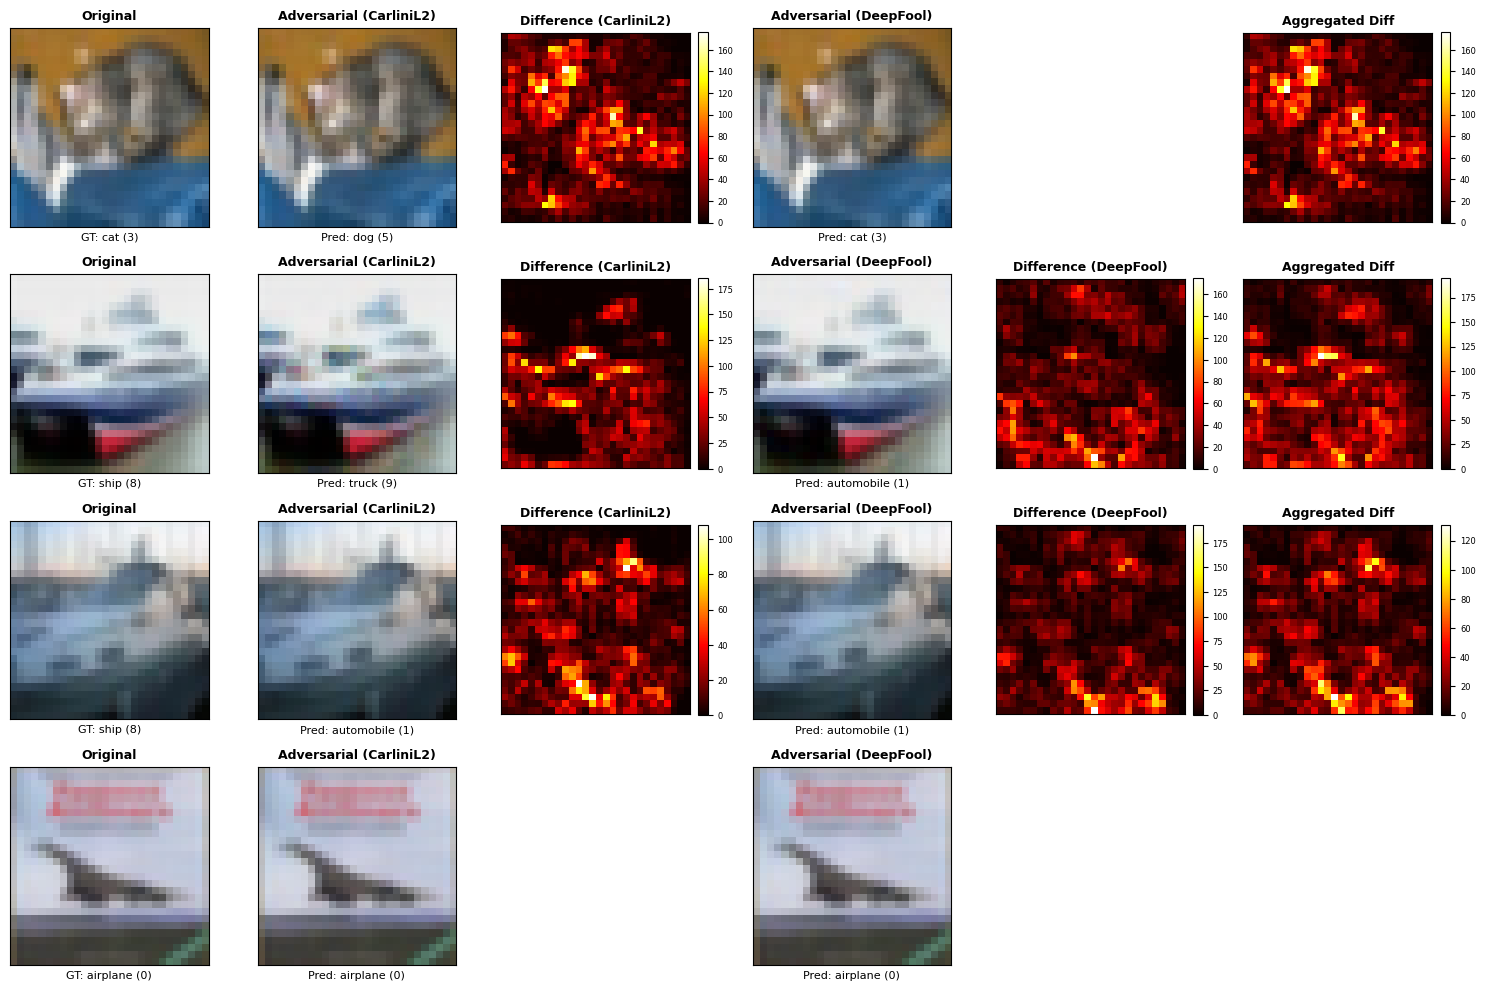

In [10]:
# Create engine with RMSE metric
metric_rmse = RMSEMetric()
engine_rmse = AdversarialEngine(
    classifier=classifier, 
    attacks=attacks, 
    metric=metric_rmse
)

# Run experiment
results_rmse = engine_rmse.run(input_imgs, ground_truth=labels.numpy())

# Visualize
_ = plotter.plot(results_rmse, class_names=class_names)

### Cosine Distance Differences

Cosine distance measures the angular difference between pixel vectors, useful for understanding directional changes in the image space.

Processing images: 100%|██████████| 4/4 [00:08<00:00,  2.16s/it]


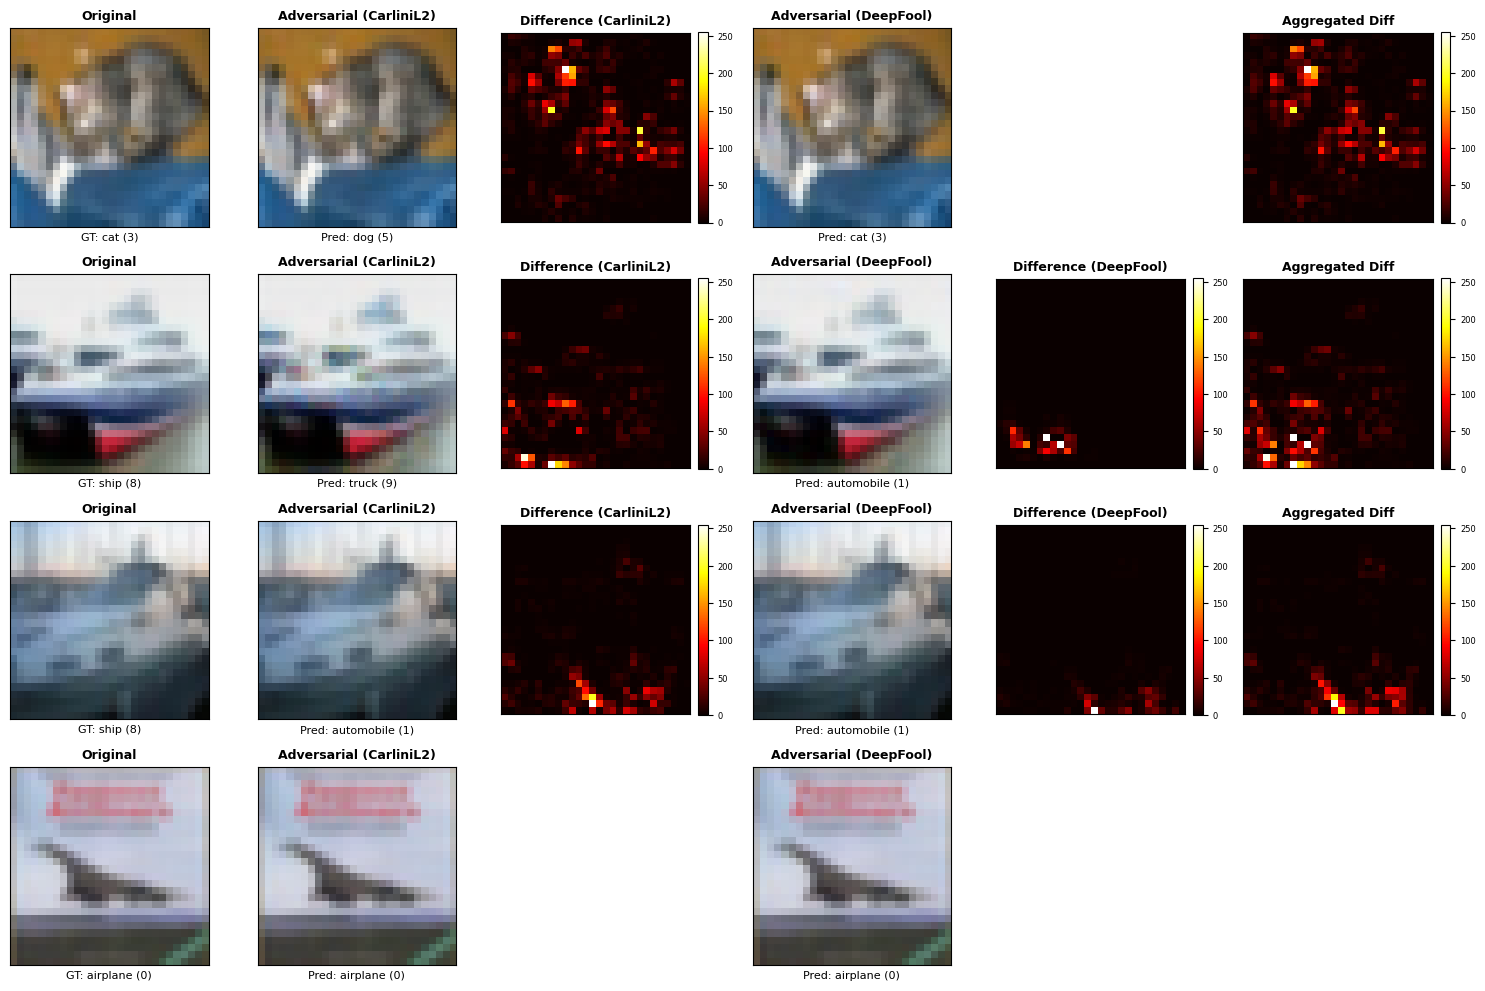

In [11]:
# Create engine with Cosine metric
metric_cosine = CosineMetric()
engine_cosine = AdversarialEngine(
    classifier=classifier, 
    attacks=attacks, 
    metric=metric_cosine
)

# Run experiment
results_cosine = engine_cosine.run(input_imgs, ground_truth=labels.numpy())

# Visualize
_ = plotter.plot(results_cosine, class_names=class_names)

### Gradient Magnitude Difference (GMD)

GMD compares the gradients/edges in the images, highlighting structural changes caused by adversarial attacks.

Processing images: 100%|██████████| 4/4 [00:08<00:00,  2.11s/it]


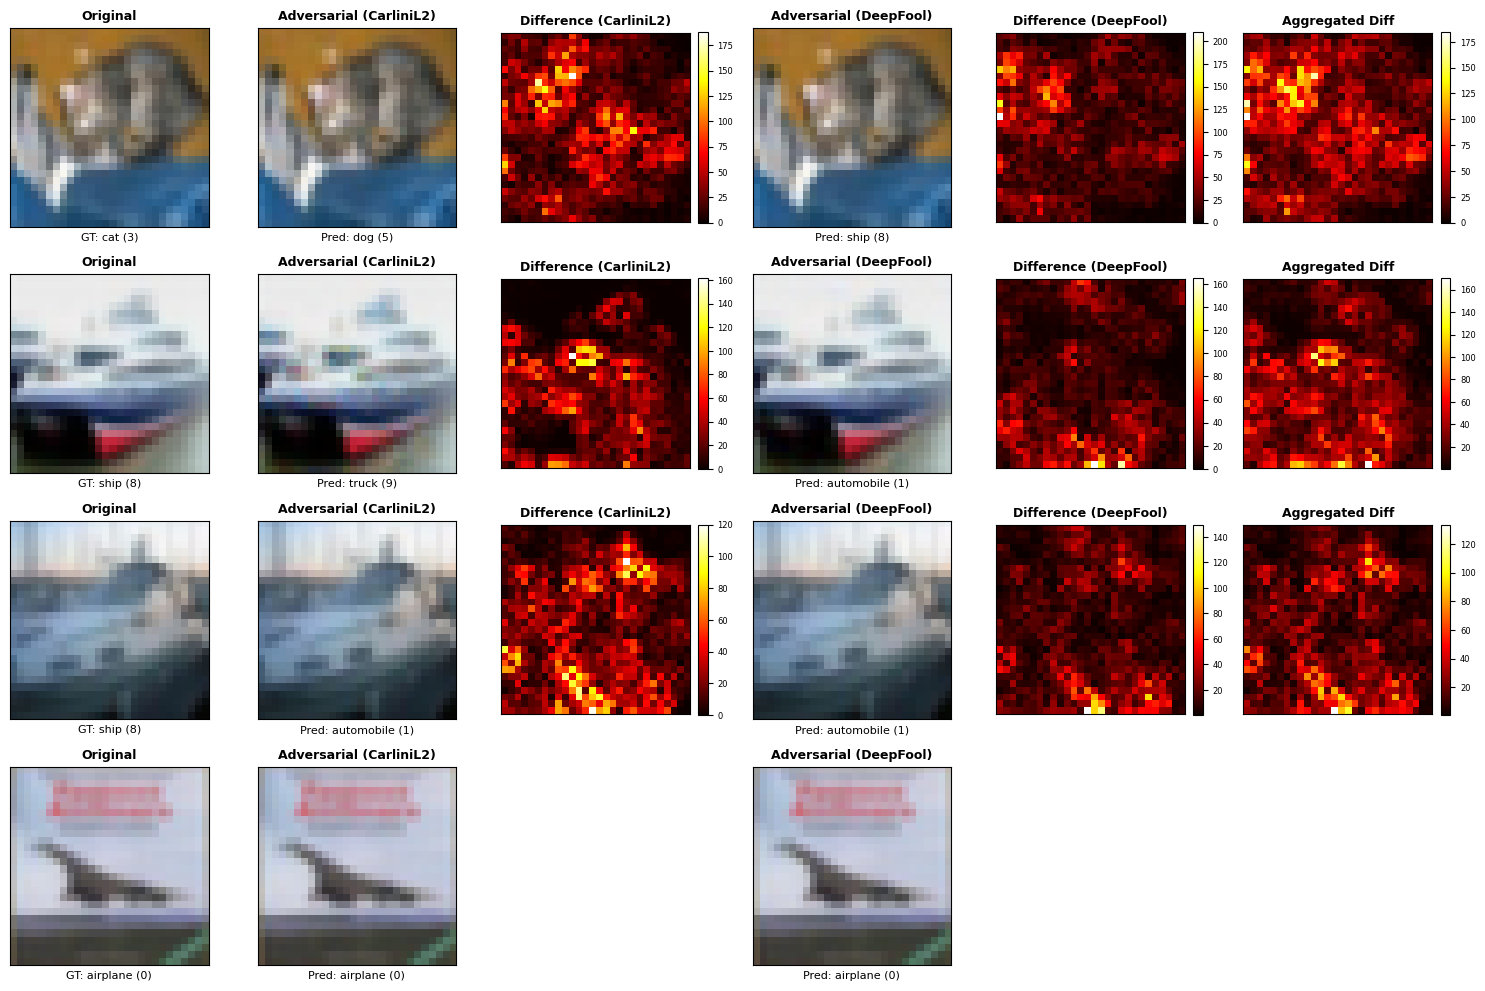

In [12]:
# Create engine with GMD metric
metric_gmd = GMDMetric()
engine_gmd = AdversarialEngine(
    classifier=classifier, 
    attacks=attacks, 
    metric=metric_gmd
)

# Run experiment
results_gmd = engine_gmd.run(input_imgs, ground_truth=labels.numpy())

# Visualize
_ = plotter.plot(results_gmd, class_names=class_names)

Processing images: 100%|██████████| 4/4 [00:09<00:00,  2.41s/it]


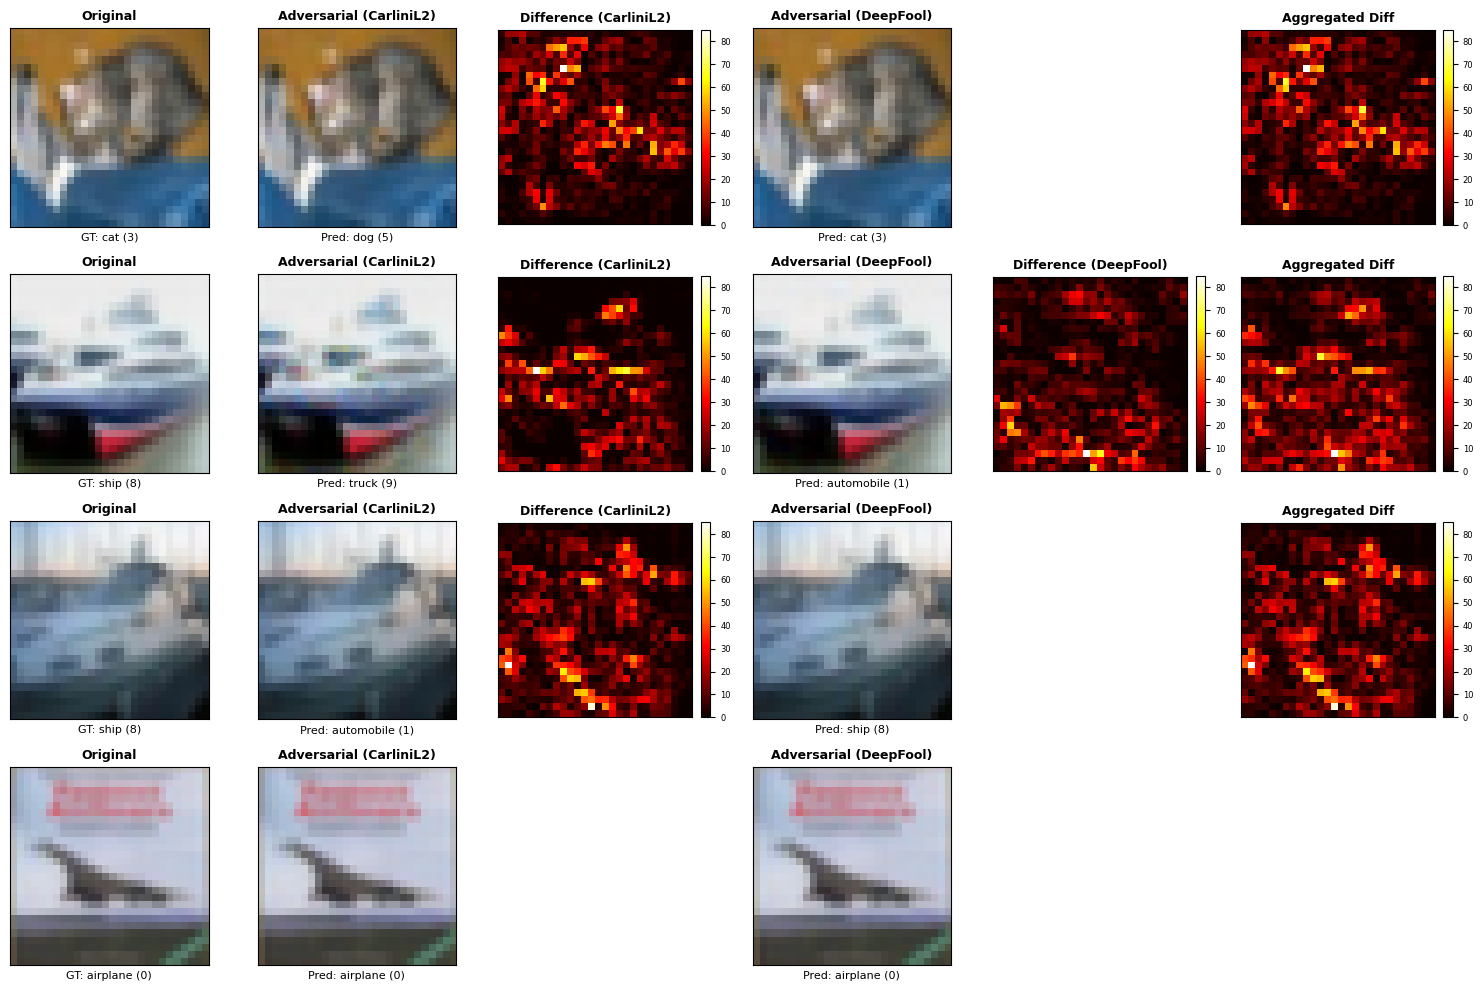

In [ ]:

def red_channe_diff(original, adversarial):
    # Example: Difference only in Red channel
    diff = np.zeros_like(original)
    # Assuming last dim is channel (H, W, C)
    diff[..., 0] = np.abs(original[..., 0] - adversarial[..., 0])
    
    # Normalize (Using for example other libraries, like sklearn)
    # But, if you do that, ensure values are in valid range for visualization [0,255] and non-negative
    return MinMaxScaler().fit_transform(diff.reshape(-1, diff.shape[-1])).reshape(diff.shape).clip(0,255)

# You can also define custom metric functions directly if prefered. If a callable is added
# It will be wrapped automatically by the engine to a MetricStrategy like this:
#
# class RedChannelDiffMetric:
#     def calculate(self, original, adversarial):
#         # Example: Difference only in Red channel
#         diff = np.zeros_like(original)
#         # Assuming last dim is channel (H, W, C)
#         diff[..., 0] = np.abs(original[..., 0] - adversarial[..., 0])
        
#       # Normalize (Using for example other libraries, like sklearn)
#       But, if you do that, ensure values are in valid range for visualization [0,255] and non-negative
#       return MinMaxScaler().fit_transform(diff.reshape(-1, diff.shape[-1])).reshape(diff.shape).clip(0,255)
    

engine_custom = AdversarialEngine(
    classifier=classifier, 
    attacks=attacks, 
    metric=red_channe_diff
)

results_custom = engine_custom.run(input_imgs, ground_truth=labels.numpy())
_ = plotter.plot(results_custom, class_names=class_names)

### Targeted Attacks

PyBox supports **targeted attacks** by leveraging the native capabilities of the ART library.

**Mechanism:**
When you provide a `target_y` argument to `explain()`, PyBox changes its behavior to strictly enforce the target class:
1.  **Re-instantiation**: It identifies which attack methods support targeted attacks (e.g., `CarliniL2Method`) and re-initializes them with `targeted=True`. This changes the optimization objective of the attack from "misclassify to anything" to "misclassify to target".
2.  **Target Injection**: It passes the specific target class(es) to the attack's `.generate(x, y=target)` method.
3.  **Success Filtering**: Finally, it verifies if the attack successfully reached the target. If the model predicts the target class (`prediction == target`), the difference heatmap is computed and added. If the attack fails, it is **ignored** (filtered from the aggregation) to avoid polluting the visual explanation with failures.

**Note:** Methods that do not support targeted attacks (e.g., `DeepFool`) will emit a warning and fall back to untargeted mode (and will likely be filtered out as they won't match the target).

In the following example, we attempt to force the classifier to predict **"Cat" (Class 3)** for all images.

In [14]:
# Define target class (3 = Cat)
target_class = 3
target_name = class_names[target_class]

print(f"Targeted Attack: Attempting to force all predictions to '{target_name}' (Class {target_class})")
print(f"Original labels: {[class_names[l.item()] for l in labels]}")

# Instantiate targeted attacks explicitly
# Note: Not all attacks support targeted mode. Carlini Methods do.
# This is high computationally expensive; using few iterations for demo

attacks_targeted = [
    ArtAttackAdapter(CarliniL0Method(classifier=classifier, targeted=True, max_iter=3, verbose=False), name="CarliniL0 (Targeted)"),
    ArtAttackAdapter(CarliniL2Method(classifier=classifier, targeted=True, max_iter=3, verbose=False), name="CarliniL2 (Targeted)"),
    ArtAttackAdapter(CarliniLInfMethod(classifier=classifier, targeted=True, max_iter=3, verbose=False), name="CarliniLInf (Targeted)"),
]

engine_targeted = AdversarialEngine(
    classifier=classifier, 
    attacks=attacks_targeted, 
    metric=MAEMetric()
)

# Prepare target labels array
target_labels = np.full(len(input_imgs), target_class)

results_targeted = engine_targeted.run(
    input_imgs, 
    ground_truth=labels.numpy(),
    target_labels=target_labels
)

# Visualize
_ = plotter.plot(results_targeted, class_names=class_names)

Targeted Attack: Attempting to force all predictions to 'cat' (Class 3)
Original labels: ['cat', 'ship', 'ship', 'airplane']


Processing images:   0%|          | 0/4 [00:13<?, ?it/s]


KeyboardInterrupt: 

### Targeted Attacks with Different Targets per Image

You can also specify a different target class for each image by passing an array:

Target per image: ['dog', 'truck', 'ship', 'cat']


Processing images: 100%|██████████| 4/4 [01:03<00:00, 15.87s/it]


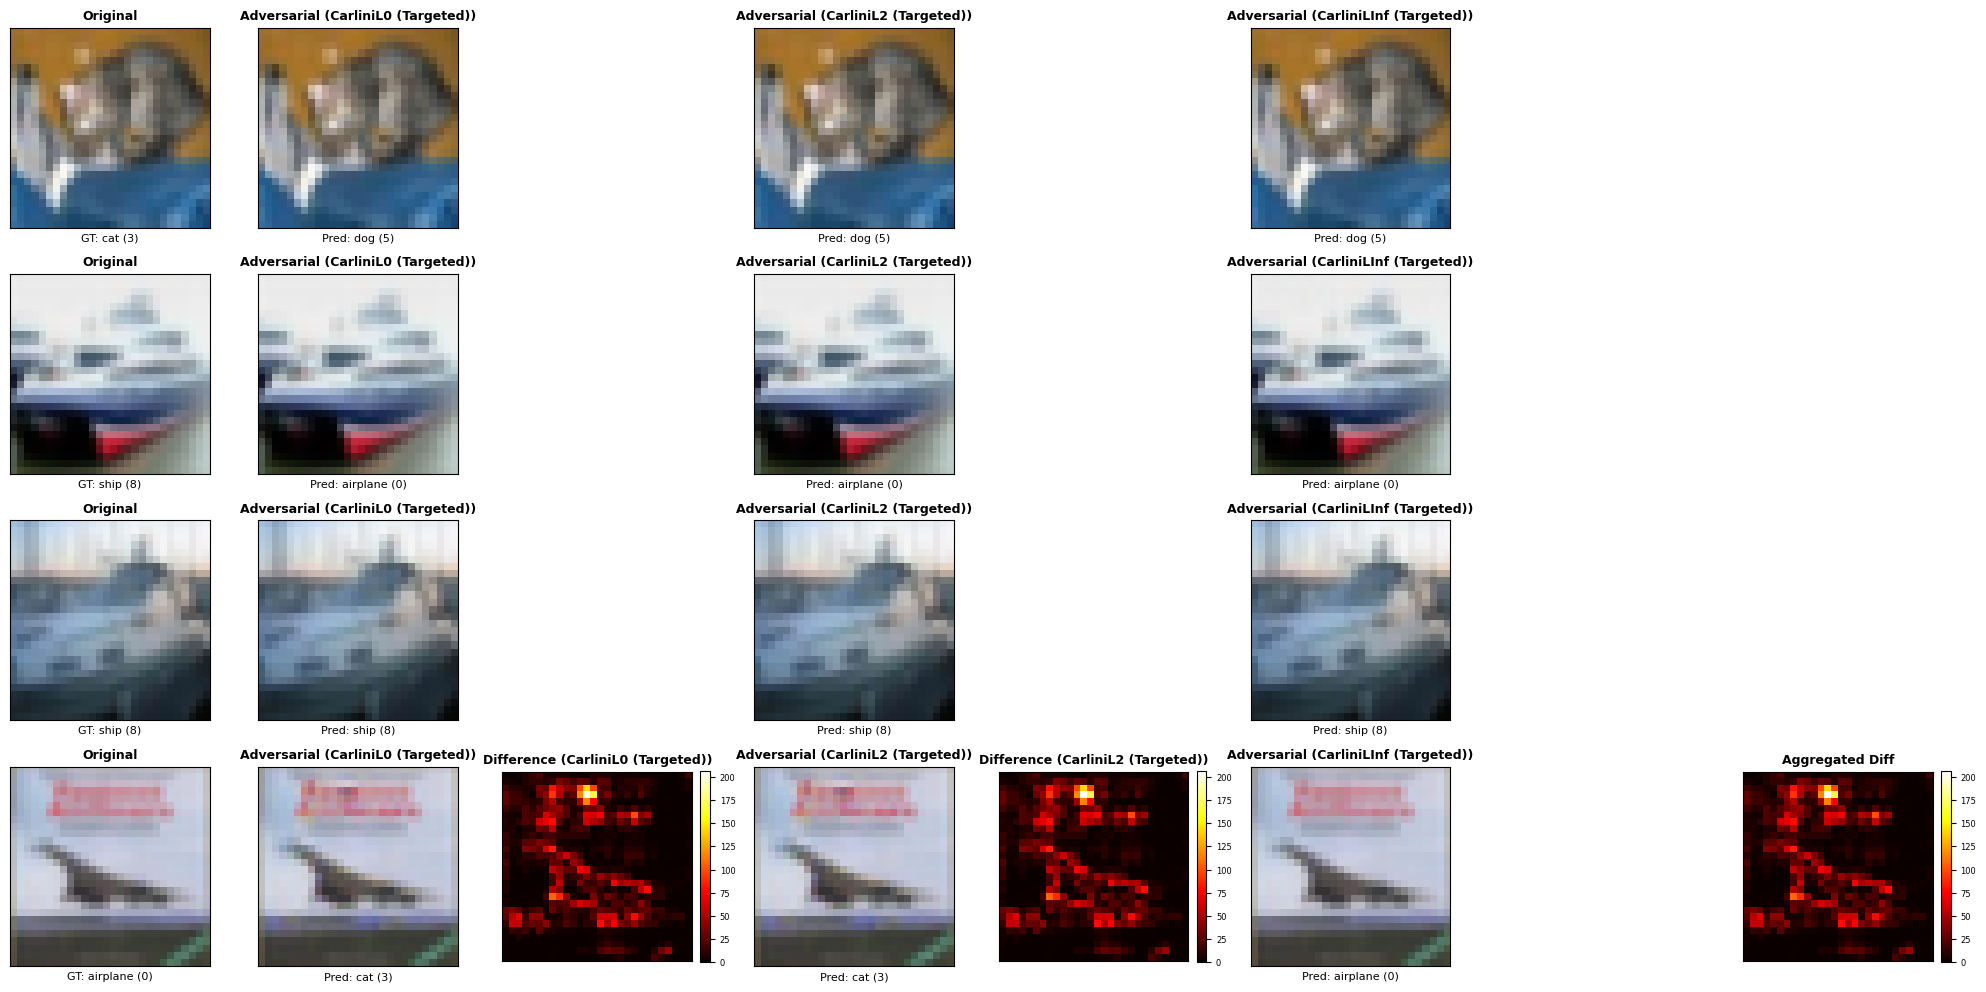

In [ ]:
# Define different targets for each image
# For example: try to convert image 0 to "dog", image 1 to "truck", image 2 to "ship"
# Ensure we have enough images in batch. If batch=4, we need 4 targets.
# The original code set targets_per_image = np.array([5, 9, 8]) assuming batch_size which might be dynamic.
# Let's adjust to current batch size.
current_batch_size = len(input_imgs)
# Cycle targets if needed
base_targets = [5, 9, 8, 3] # dog, truck, ship, cat
targets_per_image = np.array([base_targets[i % 4] for i in range(current_batch_size)])

print(f"Target per image: {[class_names[t] for t in targets_per_image]}")

# Reuse engine_targeted (it has targeted attacks configured)
results_multi_target = engine_targeted.run(
    input_imgs, 
    ground_truth=labels.numpy(),
    target_labels=targets_per_image
)

_ = plotter.plot(results_multi_target, class_names=class_names)